In [1]:
from sklearn.model_selection import cross_val_score
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
# Example of finding the best K



In [2]:
data = pd.read_csv('/Users/shreyavora/Desktop/deliriumPaper/UCSFDelirium/oversampled_data.csv')
data.head()
X = data.drop(columns=['target'], inplace=False)
y = data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
accuracies = []
for k in range(3, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())
optimal_k = accuracies.index(max(accuracies)) + 3
#print(len(accuracies))
print("Optimal K:", optimal_k)

Optimal K: 7


In [4]:
knn = KNeighborsClassifier(n_neighbors=optimal_k, weights = 'distance', metric='manhattan')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
#print(y_pred)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)
#using all of the features the 0.6153846153846154


0.7948717948717948


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
Using 155 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/155 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWar

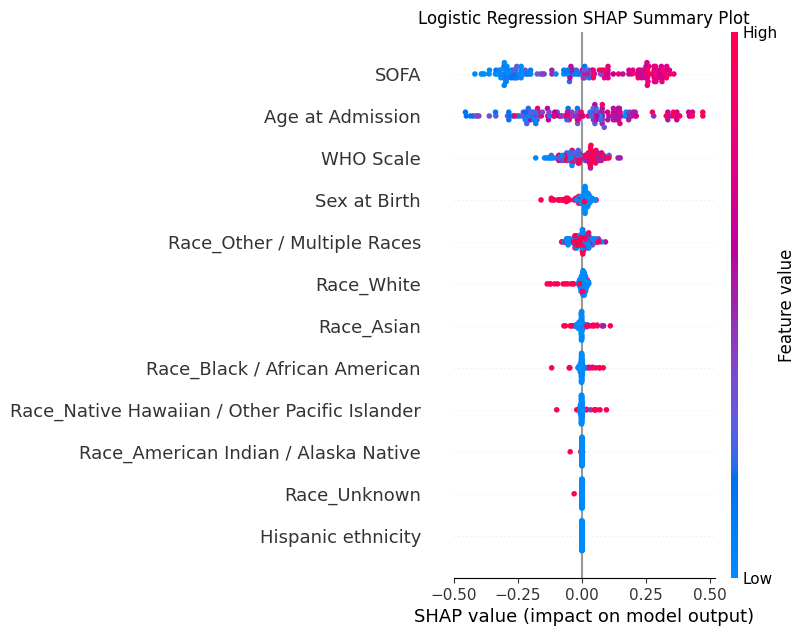

In [5]:
# Create SHAP KernelExplainer for Logistic Regression
import shap
import matplotlib.pyplot as plt

explainer = shap.KernelExplainer(lambda x: knn.predict_proba(x)[:, 1], X_train)  # Focus on the positive class (1)
shap_values = explainer.shap_values(X_train)
# Detailed SHAP summary plot
shap.summary_plot(shap_values, X_train, show=False)
plt.title("Logistic Regression SHAP Summary Plot")
plt.show()

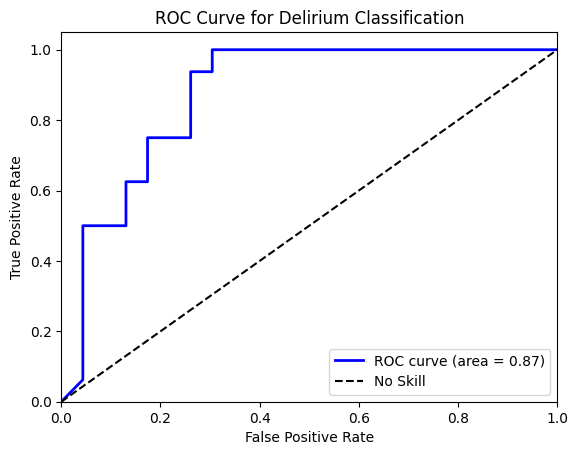

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = knn.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='black', linestyle='--', label='No Skill')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Delirium Classification')
plt.legend(loc="lower right")
plt.show()

In [7]:
feature_selection = X[['Age at Admission', 'SOFA', 'WHO Scale']]
X_trainFS, X_testFS, y_trainFS, y_testFS = train_test_split(feature_selection, y, test_size=0.2, random_state=42)


In [8]:
accuraciesFS = []
for k in range(3, 15):
    knnFS = KNeighborsClassifier(n_neighbors=k)
    scoresFS = cross_val_score(knnFS, X_trainFS, y_trainFS, cv=5, scoring='accuracy')
    accuraciesFS.append(scores.mean())
optimal_kFS = accuraciesFS.index(max(accuraciesFS)) + 3
#print(len(accuracies))
print("Optimal K:", optimal_kFS)

Optimal K: 3


In [9]:
knn_FS = KNeighborsClassifier(n_neighbors=optimal_kFS, weights = 'distance', metric='manhattan')
knn_FS.fit(X_trainFS, y_trainFS)
y_predFS = knn_FS.predict(X_testFS)
#print(y_pred)
accuracyFS = accuracy_score(y_testFS, y_predFS)
print(accuracyFS)
#using all of the features the 0.6153846153846154


0.7692307692307693


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
Using 155 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/155 [00:00<?, ?it/s]

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:493: UserWar

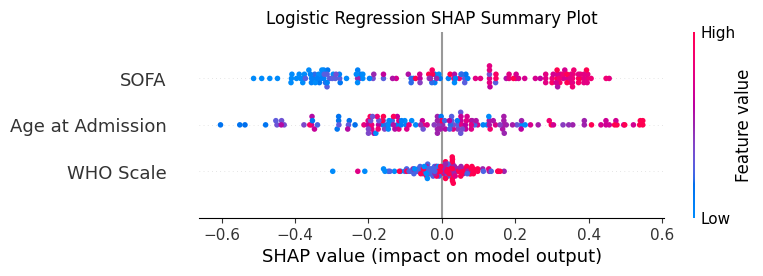

In [10]:
explainerFS = shap.KernelExplainer(lambda x: knn_FS.predict_proba(x)[:, 1], X_trainFS)  # Focus on the positive class (1)
shap_valuesFS = explainerFS.shap_values(X_trainFS)
# Detailed SHAP summary plot
shap.summary_plot(shap_valuesFS, X_trainFS, show=False)
plt.title("Logistic Regression SHAP Summary Plot")
plt.show()